# EDA — BTS On-Time Performance
 Aqui cubrinos los puntos 1.b y 1.c que estableció el docente
 
Usamos DuckDB directo sobre el Parquet (`data/parquet`) — es rápido incluso con 21M de filas, porque no carga todo a memoria de una vez.


Instalación de paquetes necesarios

In [ ]:
import subprocess
import os
import sys

REQUIRED_PACKAGES = [
    'duckdb',
    'dask',
    'pyarrow',
    'prefect'
]

In [13]:
def instalar_paquete():
    for paquete in REQUIRED_PACKAGES:
        nompre_import = paquete.split('==')[0]
        try:
            __import__(nompre_import)
        except ImportError:
            print(f"Instalando {paquete} ...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete])
try:
    instalar_paquete()
except Exception as e:
    print(f"Error al instalar paquetes: {e}")
    sys.exit(1)

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()
PARQUET = "data/parquet/**/*.parquet"

pd.set_option("display.max_columns", None)


Ejecución descarga de datos

In [14]:
archivo_script = "./scripts/flujo_ingesta_prefect.py"
subprocess.check_call([sys.executable, archivo_script])

22:40:01.964 | INFO    | Flow run 'hot-magpie' - Beginning flow run 'hot-magpie' for flow 'ingesta-y-analitica-bts'
22:40:01.970 | INFO    | Flow run 'hot-magpie' - View at https://app.prefect.cloud/account/d403af70-0708-4744-a013-6c003ee0875a/workspace/1b00c0e9-77d0-448e-a2b1-36a3dda32f04/runs/flow-run/06abf279-1688-79cb-8000-095fa15b78cf
22:41:25.745 | INFO    | Task run 'descargar_mes-dc6' - 2023-01 descargado (27.1 MB)
22:41:25.749 | INFO    | Task run 'descargar_mes-dc6' - Finished in state Completed()
22:41:38.388 | INFO    | Task run 'validar_y_convertir-2bb' - On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2023_1.zip: 538,837 filas convertidas a Parquet
22:41:38.416 | INFO    | Task run 'validar_y_convertir-2bb' - Finished in state Completed()
22:45:42.362 | INFO    | Task run 'descargar_mes-704' - 2023-02 descargado (24.7 MB)
22:45:42.366 | INFO    | Task run 'descargar_mes-704' - Finished in state Completed()
22:45:51.470 | INFO    | Task run 'validar_y_convertir-

0

## 1. Tipos de datos


In [15]:
esquema = con.execute(f"""
    DESCRIBE SELECT * FROM parquet_scan('{PARQUET}') LIMIT 1
""").fetchdf()
esquema

,column_name,column_type,null,key,default,extra
0,Quarter,BIGINT,YES,None,None,None
1,DayofMonth,BIGINT,YES,None,None,None
2,DayOfWeek,BIGINT,YES,None,None,None
3,FlightDate,VARCHAR,YES,None,None,None
4,Reporting_Airline,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
105,Div5WheelsOff,DOUBLE,YES,None,None,None
106,Div5TailNum,DOUBLE,YES,None,None,None
107,Unnamed: 109,DOUBLE,YES,None,None,None
108,Month,BIGINT,YES,None,None,None


Se identificaron las variables disponibles en el dataset y sus tipos de datos.
 
Esta revisión permite distinguir variables numéricas, categóricas y temporales, y sirve como base para seleccionar las variables que pueden utilizarse posteriormente en el análisis y modelado.

## 2. Variable objetivo: `ArrDel15`

Es el indicador oficial de BTS: 1 si el vuelo llegó con 15 minutos o más de atraso, 0 si no. 

In [17]:
dist_objetivo = con.execute(f"""
    SELECT
        ArrDel15,
        COUNT(*) AS vuelos,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentaje
    FROM parquet_scan('{PARQUET}')
    WHERE ArrDel15 IS NOT NULL
    GROUP BY ArrDel15
""").fetchdf()
dist_objetivo


,ArrDel15,vuelos,porcentaje
0,0.0,16216831,78.77
1,1.0,4371303,21.23


La variable ArrDel15 representa si un vuelo llegó con 15 minutos o más de retraso. 

Analizar su distribución permite determinar si existe desbalance entre vuelos atrasados y no atrasados. Este aspecto será importante posteriormente para seleccionar métricas adecuadas de evaluación del modelo, evitando depender únicamente de la exactitud

## 3. Medidas de tendencia central — variables numéricas clave

`ArrDelay`, `DepDelay` permiten caracterizar históricamente la magnitud de los retrasos, mientras  `Distance` puede utilizarse posteriormente como variable explicativa en el modelo.

In [18]:
estadisticas = con.execute(f"""
    SELECT
        'ArrDelay' AS variable,
        ROUND(AVG(ArrDelay), 1) AS media,
        ROUND(MEDIAN(ArrDelay), 1) AS mediana,
        ROUND(STDDEV(ArrDelay), 1) AS desv_estandar,
        MIN(ArrDelay) AS minimo,
        MAX(ArrDelay) AS maximo
    FROM parquet_scan('{PARQUET}')
    WHERE ArrDelay IS NOT NULL

    UNION ALL

    SELECT 'DepDelay', ROUND(AVG(DepDelay),1), ROUND(MEDIAN(DepDelay),1),
           ROUND(STDDEV(DepDelay),1), MIN(DepDelay), MAX(DepDelay)
    FROM parquet_scan('{PARQUET}') WHERE DepDelay IS NOT NULL

    UNION ALL

    SELECT 'Distance', ROUND(AVG(Distance),1), ROUND(MEDIAN(Distance),1),
           ROUND(STDDEV(Distance),1), MIN(Distance), MAX(Distance)
    FROM parquet_scan('{PARQUET}') WHERE Distance IS NOT NULL
""").fetchdf()
estadisticas


,variable,media,mediana,desv_estandar,minimo,maximo
0,ArrDelay,7.4,-6.0,58.3,-128.0,4405.0
1,DepDelay,12.8,-2.0,56.3,-115.0,4413.0
2,Distance,837.2,683.0,599.2,11.0,5095.0


**Nota para el documento:** si ves un `maximo` de ArrDelay/DepDelay muy alto (cientos o miles de minutos), no es un error de datos — son casos reales de cancelaciones reprogramadas o eventos extremos (tormentas, paros). Vale la pena mencionarlo como un patrón, no como un dato sucio a borrar sin más.

## 4. Valores faltantes

Se evaluó la proporción de valores faltantes en las variables principales del análisis. Este paso permite identificar variables que podrían requerir imputación, eliminación de registros o un tratamiento especial antes del modelado.


In [19]:
columnas_clave = [
    "ArrDel15", "ArrDelay", "DepDelay", "Reporting_Airline",
    "Origin", "Dest", "Distance", "CRSDepTime", "DayOfWeek", "Month"
]

filas_nulos = []
for columna in columnas_clave:
    resultado = con.execute(f"""
        SELECT
            COUNT(*) AS total,
            SUM(CASE WHEN {columna} IS NULL THEN 1 ELSE 0 END) AS nulos
        FROM parquet_scan('{PARQUET}')
    """).fetchone()
    total, nulos = resultado
    filas_nulos.append({
        "columna": columna,
        "nulos": nulos,
        "pct_nulos": round(100 * nulos / total, 2),
    })

pd.DataFrame(filas_nulos)


,columna,nulos,pct_nulos
0,ArrDel15,340445,1.63
1,ArrDelay,340445,1.63
2,DepDelay,276090,1.32
3,Reporting_Airline,0,0.00
4,Origin,0,0.00
5,Dest,0,0.00
6,Distance,0,0.00
7,CRSDepTime,0,0.00
8,DayOfWeek,0,0.00
9,Month,0,0.00


## 5. Patrones temporales: día de la semana y franja horaria

El docente pide "identificar patrones en los datos" — el comportamiento por día de la semana y por hora del día suele ser el patrón más fuerte en puntualidad de vuelos.


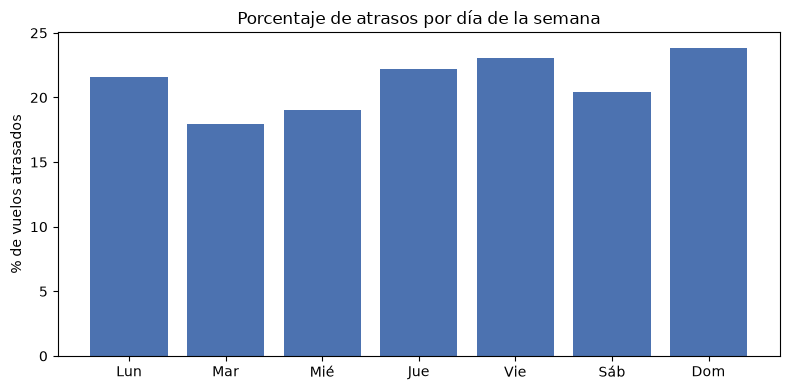

,DayOfWeek,vuelos,pct_atrasados,dia
0,1,3084884,21.57,Lun
1,2,2830629,17.94,Mar
2,3,2861728,19.07,Mié
3,4,3044496,22.24,Jue
4,5,3065545,23.03,Vie
5,6,2659850,20.46,Sáb
6,7,3041002,23.85,Dom


In [20]:
por_dia_semana = con.execute(f"""
    SELECT
        DayOfWeek,
        COUNT(*) AS vuelos,
        ROUND(100.0 * SUM(CASE WHEN ArrDel15 = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_atrasados
    FROM parquet_scan('{PARQUET}')
    WHERE ArrDel15 IS NOT NULL
    GROUP BY DayOfWeek
    ORDER BY DayOfWeek
""").fetchdf()

dias = {1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb", 7: "Dom"}
por_dia_semana["dia"] = por_dia_semana["DayOfWeek"].map(dias)

plt.figure(figsize=(8, 4))
plt.bar(por_dia_semana["dia"], por_dia_semana["pct_atrasados"], color="#4C72B0")
plt.ylabel("% de vuelos atrasados")
plt.title("Porcentaje de atrasos por día de la semana")
plt.tight_layout()
plt.show()

por_dia_semana


El porcentaje de vuelos atrasados presenta variaciones según el día de la semana. Esto indica que el componente temporal puede aportar información útil al modelo y justifica conservar DayOfWeek como una variable candidata.

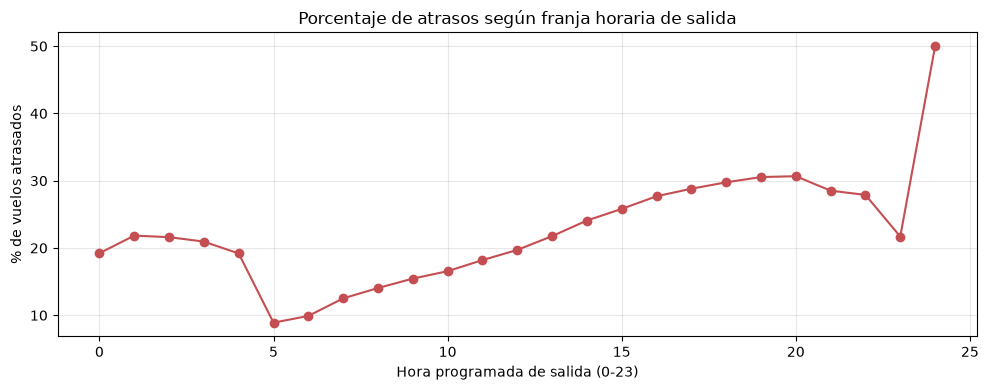

,hora_programada,vuelos,pct_atrasados
0,0.0,33941,19.22
1,1.0,11163,21.84
2,2.0,4498,21.61
3,3.0,2482,20.95
4,4.0,1240,19.19
5,5.0,585931,8.90
6,6.0,1447639,9.90
7,7.0,1446306,12.51
8,8.0,1404705,14.05
9,9.0,1159734,15.45


In [21]:
por_hora = con.execute(f"""
    SELECT
        FLOOR(CRSDepTime / 100) AS hora_programada,
        COUNT(*) AS vuelos,
        ROUND(
            100.0 * SUM(CASE WHEN ArrDel15 = 1 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS pct_atrasados
    FROM parquet_scan('{PARQUET}')
    WHERE ArrDel15 IS NOT NULL
      AND CRSDepTime IS NOT NULL
    GROUP BY hora_programada
    ORDER BY hora_programada
""").fetchdf()

plt.figure(figsize=(10, 4))
plt.plot(por_hora["hora_programada"], por_hora["pct_atrasados"], marker="o", color="#C44E52")
plt.xlabel("Hora programada de salida (0-23)")
plt.ylabel("% de vuelos atrasados")
plt.title("Porcentaje de atrasos según franja horaria de salida")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

por_hora


La hora programada de salida muestra variaciones en la proporción de vuelos atrasados. Esto sugiere que el momento del día puede estar relacionado con la puntualidad y justifica crear posteriormente una variable derivada de franja horaria.

## 6. Patrones por aerolínea y por ruta

Ya tienes el resumen por aerolínea/mes (de la Unidad 2). Aquí lo resumimos a nivel aerolínea completa, y agregamos las rutas (origen→destino) con más atrasos.


In [22]:
por_aerolinea = con.execute(f"""
    SELECT
        Reporting_Airline,
        COUNT(*) AS vuelos,
        ROUND(100.0 * SUM(CASE WHEN ArrDel15 = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_atrasados
    FROM parquet_scan('{PARQUET}')
    WHERE ArrDel15 IS NOT NULL
    GROUP BY Reporting_Airline
    ORDER BY pct_atrasados DESC
""").fetchdf()
por_aerolinea


,Reporting_Airline,vuelos,pct_atrasados
0,F9,571133,29.28
1,B6,730301,27.79
2,NK,705662,25.16
3,AA,2847015,24.98
4,G4,359199,24.21
5,OH,651427,22.35
6,AS,724893,21.60
7,WN,4202672,21.27
8,UA,2252227,20.66
9,MQ,791847,20.16


Se observan diferencias en el porcentaje de atrasos entre aerolíneas. Estas diferencias muestran que la aerolínea puede ser una variable predictiva relevante, aunque no deben interpretarse de manera causal, ya que también pueden estar asociadas con rutas, aeropuertos, horarios y otras condiciones operacionales.

In [23]:
top_rutas_atrasadas = con.execute(f"""
    SELECT
        Origin, Dest,
        COUNT(*) AS vuelos,
        ROUND(100.0 * SUM(CASE WHEN ArrDel15 = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_atrasados
    FROM parquet_scan('{PARQUET}')
    WHERE ArrDel15 IS NOT NULL
    GROUP BY Origin, Dest
    HAVING COUNT(*) > 5000   -- solo rutas con volumen suficiente para ser representativas
    ORDER BY pct_atrasados DESC
    LIMIT 15
""").fetchdf()
top_rutas_atrasadas


,Origin,Dest,vuelos,pct_atrasados
0,DFW,MCO,14398,34.55
1,DFW,SFO,11845,34.23
2,DFW,SAN,10226,33.32
3,DFW,SMF,5082,32.59
4,DFW,MSY,8540,32.34
5,BOS,PBI,5894,32.32
6,DFW,LAS,17174,31.96
7,DFW,SAT,12360,31.89
8,BOS,SJU,5715,31.81
9,LAS,SFO,17236,31.80


Para evitar conclusiones basadas en rutas con muy pocas observaciones, se limitaron los resultados a rutas con más de 5.000 vuelos. Posteriormente se ordenaron según su porcentaje de atrasos

## 7. Variables candidatas para el modelo (cierre de Unidad 5)

Con lo anterior, estas son las candidatas naturales a features para predecir `ArrDel15`:

- **Categóricas**: `Reporting_Airline`, `Origin`, `Dest`, `DayOfWeek`, `Month`
- **Derivada de `CRSDepTime`**: franja horaria (mañana/tarde/noche), porque el patrón por hora es claro arriba
- **Numérica**: `Distance`

**Importante — columnas que NO deben usarse como feature (fuga de información):** `DepDelay`, `ArrDelay`, `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` solo se conocen **después** de que el vuelo ya ocurrió — no están disponibles en el momento en que querrías predecir si un vuelo *futuro* se va a atrasar. Usarlas como feature daría una exactitud artificialmente perfecta en el modelo, pero inútil en la práctica. Esto es un hallazgo importante para documentar en "análisis preliminar" (punto 1.c).

## 8. Análisis preliminar — ¿falta información de contexto? (punto 1.c)

Basado en lo explorado:

- El dataset **sí incluye** las razones de atraso codificadas (`CarrierDelay`, `WeatherDelay`, etc.), pero como se explicó arriba, son posteriores al hecho — útiles para *explicar* atrasos pasados, no para *predecir* futuros.
- **No incluye** clima real (temperatura, visibilidad, viento) en el momento de salida — eso explicaría por qué ciertas rutas/temporadas tienen más atrasos, pero no viene en este dataset. Si hubiera tiempo, cruzar con datos de clima (NOAA) sería el "dato de contexto adicional" que pide el punto 1.c — queda como línea de trabajo futura, no bloqueante para el proyecto actual.
- **No incluye** el tráfico aéreo del aeropuerto en tiempo real (cuántos vuelos salían a la misma hora) — eso explicaría congestión, pero tampoco es necesario para responder la pregunta de negocio actual.

**Conclusión:** El dataset contiene información suficiente para desarrollar una primera versión del modelo de clasificación de `ArrDel15`. Sin embargo, incorporar posteriormente variables externas, como condiciones meteorológicas o niveles de congestión aeroportuaria, podría mejorar su capacidad predictiva y explicativa.


In [24]:
volumen = con.execute(f"""
    SELECT COUNT(*) AS total_vuelos
    FROM parquet_scan('{PARQUET}')
""").fetchdf()

volumen

,total_vuelos
0,20928579
